In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

sys.path.append('../src')

from data_pipeline import load_all_raw_data

from data_analysis import (
    filter_data_until_date, temporal_split_data, 
)

from plots.data_plot import (
    plot_user_analysis, plot_temporal_analysis, 
    plot_station_analysis, plot_activity_heatmap, 
    print_summary_statistics
)

from preprocess import (
    analyze_users_for_visualization, 
    analyze_trips_for_visualization
)

from weather_data import WeatherDataCollector


⚠️ Warning: Testing module not available. Pipeline will run without validation.


In [3]:

raw_data_dir = Path('../data/raw')
save_dir = Path('../data/raw/combined')

users_df, trips_df = load_all_raw_data(raw_data_dir, save_dir, verbose=True)

print(f"Datos cargados: {len(users_df):,} usuarios, {len(trips_df):,} viajes")


INICIANDO CARGA OPTIMIZADA DE DATOS RAW
Cargando datos de usuarios...
Cargando: usuarios_ecobici_2020.csv
   107,166 filas cargadas en 0.30s
Cargando: usuarios_ecobici_2021.csv
   81,577 filas cargadas en 0.17s
Cargando: usuarios_ecobici_2022.csv
   105,997 filas cargadas en 0.41s
Cargando: usuarios_ecobici_2023.csv
   136,066 filas cargadas en 0.39s
Cargando: usuarios_ecobici_2024.csv
   197,079 filas cargadas en 0.40s
Concatenando 5 archivos con 627,885 filas totales...
   Concatenacion completada en 0.29s
Total usuarios: 627,885 registros
Columnas usuarios: ['id_usuario', 'genero_usuario', 'edad_usuario', 'fecha_alta', 'hora_alta']

Cargando datos de viajes...
Cargando: trips_2020.csv
Found concatenated coordinates, separating...
   2,415,597 filas cargadas en 46.10s
Cargando: trips_2021.csv
Found concatenated coordinates, separating...
   2,860,091 filas cargadas en 55.83s
Cargando: trips_2022.csv
   2,922,805 filas cargadas en 45.57s
Cargando: trips_2023.csv
   2,622,331 filas car

In [4]:
print("🔍 ORIGINAL RAW DATA ANALYSIS (BEFORE PREPROCESSING)")
print("=" * 60)

print("Number of null values per column (ORIGINAL):")
nan_counts_original = trips_df.isnull().sum()
print(nan_counts_original)

print("\nPercentage of null values per column (ORIGINAL):")
nan_percentages_original = (trips_df.isnull().sum() / len(trips_df) * 100).round(2)
print(nan_percentages_original)

print("\nMin and max values per column:")
for col in trips_df.columns:
    try:
        min_val = trips_df[col].min()
        max_val = trips_df[col].max()
        print(f"\n{col}:")
        print(f"  Min: {min_val}")
        print(f"  Max: {max_val}")
    except:
        print(f"\n{col}: Cannot calculate min/max (likely non-numeric)")

print(f"\nOriginal dataset shape: {trips_df.shape}")
print(f"Original columns: {list(trips_df.columns)}")

key_cols = ['id_recorrido', 'id_estacion_origen', 'id_estacion_destino', 'id_usuario', 'duracion_recorrido', 'genero']


🔍 ORIGINAL RAW DATA ANALYSIS (BEFORE PREPROCESSING)
Number of null values per column (ORIGINAL):
id_recorrido                      0
duracion_recorrido                0
fecha_origen_recorrido            0
id_estacion_origen                0
nombre_estacion_origen            0
direccion_estacion_origen         0
long_estacion_origen              0
lat_estacion_origen               0
fecha_destino_recorrido        3379
id_estacion_destino              43
nombre_estacion_destino          43
direccion_estacion_destino       43
long_estacion_destino            43
lat_estacion_destino             43
id_usuario                        0
modelo_bicicleta                  0
genero                        76061
dtype: int64

Percentage of null values per column (ORIGINAL):
id_recorrido                  0.00
duracion_recorrido            0.00
fecha_origen_recorrido        0.00
id_estacion_origen            0.00
nombre_estacion_origen        0.00
direccion_estacion_origen     0.00
long_estacion_orig

In [5]:

users_filtered, trips_filtered = filter_data_until_date(
    users_df, trips_df, 
    max_date="2024-08-31",
    verbose=False
)


data_splits = temporal_split_data(
    users_filtered, trips_filtered,
    train_end_date="2023-06-30",  # Train until jun 2023
    val_end_date="2023-12-31",    # Val jul-dec 2023  
    test_end_date="2024-08-31",   # Test jan-aug 2024
    verbose=False
)


### Weather



In [6]:
weather_collector = WeatherDataCollector(cache_dir='../data/cache')

def load_and_summarize_weather_data(weather_collector: WeatherDataCollector, weather_file_path: str = "../data/raw/meteo/hourly_open_meteo.csv"):
    """
    load weather data and print summary statistics
    
    parameters:
        weather_collector: weather data collector
        weather_file_path: path to weather data file
    
    returns:
        weather_df: dataframe with weather data
        weather_summary: dictionary with weather statistics
    """
    # initialize collector and load data
    weather_df = weather_collector.load_weather_data(weather_file_path)
    
    # print basic info
    print(f"\nweather dataframe shape: {weather_df.shape}")
    print(f"weather columns: {list(weather_df.columns)}")
    print(f"date range: {weather_df['date'].min()} to {weather_df['date'].max()}")
    
    # get and print summary stats
    weather_summary = weather_collector.get_weather_summary(weather_df)
    print(f"\nweather summary:")
    print(f"total records: {weather_summary['total_records']:,}")
    print(f"temperature range: {weather_summary['temperature_stats']['min']:.1f}°C to {weather_summary['temperature_stats']['max']:.1f}°C")
    print(f"mean temperature: {weather_summary['temperature_stats']['mean']:.1f}°C")
    print(f"total precipitation: {weather_summary['precipitation_stats']['total_mm']:.1f}mm")
    print(f"rainy hours: {weather_summary['precipitation_stats']['rainy_hours']:,}")
    print(f"mean wind speed: {weather_summary['wind_stats']['mean_speed_10m']:.1f} km/h")
    
    return weather_df, weather_summary

# load and summarize weather data
weather_df, weather_summary = load_and_summarize_weather_data(weather_collector)



weather dataframe shape: (43848, 32)
weather columns: ['date', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'weather_code', 'pressure_msl', 'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'et0_fao_evapotranspiration', 'vapour_pressure_deficit', 'wind_speed_10m', 'wind_speed_100m', 'wind_direction_10m', 'wind_direction_100m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm', 'soil_temperature_7_to_28cm', 'soil_temperature_28_to_100cm', 'soil_temperature_100_to_255cm', 'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm', 'soil_moisture_28_to_100cm', 'soil_moisture_100_to_255cm', 'sunshine_duration', 'is_day', 'direct_radiation']
date range: 2020-01-01 03:00:00+00:00 to 2025-01-01 02:00:00+00:00

weather summary:
total records: 43,848
temperature range: -1.4°C to 38.9°C
mean temperature: 17.5°C
total precipitation: 4470.5mm
rainy hours: 4,079
mean wind speed: 15.9 km/h


In [7]:

print(f"\nfirst 5 rows of weather data:")
weather_df.head(5)



first 5 rows of weather data:


,date,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,weather_code,pressure_msl,surface_pressure,...,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm,sunshine_duration,is_day,direct_radiation
0,2020-01-01 03:00:00+00:00,21.311000,87.557816,19.161001,22.377872,0.0,0.0,1.0,1010.7,1008.47485,...,24.361,22.961,18.861,0.468,0.484,0.387,0.455,0.0,0.0,0.0
1,2020-01-01 04:00:00+00:00,20.661001,90.842300,19.111000,21.789688,0.0,0.0,1.0,1010.9,1008.66974,...,24.261,22.961,18.861,0.468,0.483,0.388,0.455,0.0,0.0,0.0
2,2020-01-01 05:00:00+00:00,20.211000,92.242134,18.911001,21.202090,0.0,0.0,0.0,1011.1,1008.86580,...,24.111,22.961,18.861,0.468,0.483,0.388,0.455,0.0,0.0,0.0
3,2020-01-01 06:00:00+00:00,19.961000,92.516730,18.711000,20.706026,0.0,0.0,3.0,1011.0,1008.76410,...,24.011,22.961,18.861,0.468,0.482,0.388,0.455,0.0,0.0,0.0
4,2020-01-01 07:00:00+00:00,19.761000,91.640465,18.361000,20.033457,0.0,0.0,3.0,1011.2,1008.96210,...,23.861,22.961,18.861,0.468,0.482,0.388,0.455,0.0,0.0,0.0


In [8]:

# create enhanced weather features for better analysis
weather_with_features = weather_collector.create_weather_features(weather_df)
print(f"created additional weather features")
print(f"enhanced weather columns: {len(weather_with_features.columns)} total")

# weather_with_features.head()


created additional weather features
enhanced weather columns: 45 total


In [9]:

# match weather to training trips (taking a sample for demonstration)
print("\nmatching weather to trip data...")

# match weather conditions to trips
trips_with_weather = weather_collector.match_weather_to_trips(
    trips_filtered, 
    # weather_with_features,
    weather_df,
    date_column='fecha_origen_recorrido'
)

print(f"\ntrips with weather data shape: {trips_with_weather.shape}")
print(f"new columns added: {len(trips_with_weather.columns) - len(trips_filtered.columns)}")




matching weather to trip data...
matching weather conditions to trips...
finding weather conditions for each trip...
matched weather data for 12,976,053 out of 12,976,053 trips (100.0%)

trips with weather data shape: (12976053, 48)
new columns added: 31


In [10]:
def analyze_weather_impact(trips_df):
    """analyze impact of weather conditions on bike usage and trip duration"""
    results = {}
    
    # temperature analysis
    if 'weather_temperature_2m' in trips_df.columns:
        temp_ranges = pd.cut(trips_df['weather_temperature_2m'],
                           bins=[-float('inf'), 10, 15, 20, 25, 30, float('inf')],
                           labels=['<10°C', '10-15°C', '15-20°C', '20-25°C', '25-30°C', '>30°C'])
        results['temperature'] = {
            'usage': temp_ranges.value_counts().sort_index(),
            'duration': trips_df.groupby(temp_ranges)['duracion_recorrido'].mean() if 'duracion_recorrido' in trips_df.columns else None
        }
    
    # rain analysis
    if 'weather_is_raining' in trips_df.columns:
        results['rain'] = {
            'usage': trips_df['weather_is_raining'].value_counts(),
            'duration': trips_df.groupby('weather_is_raining')['duracion_recorrido'].mean() if 'duracion_recorrido' in trips_df.columns else None
        }
    
    # wind analysis
    if 'weather_wind_speed_10m' in trips_df.columns:
        wind_ranges = pd.cut(trips_df['weather_wind_speed_10m'],
                           bins=[0, 10, 20, 30, float('inf')],
                           labels=['calm (0-10)', 'light (10-20)', 'moderate (20-30)', 'strong (>30)'])
        results['wind'] = {
            'usage': wind_ranges.value_counts().sort_index()
        }
    
    return results

def print_weather_analysis(results, total_trips):
    """print formatted weather analysis results"""
    # temperature impact
    if 'temperature' in results:
        print("temperature impact on bike usage:")
        for temp_range, count in results['temperature']['usage'].items():
            percentage = count / total_trips * 100
            print(f"  {temp_range}: {count:,} trips ({percentage:.1f}%)")
        
        if results['temperature']['duration'] is not None:
            print("\naverage trip duration by temperature:")
            for temp_range, avg_duration in results['temperature']['duration'].items():
                print(f"  {temp_range}: {avg_duration:.0f} seconds")
    
    # rain impact
    if 'rain' in results:
        print("\nrain impact on bike usage:")
        for is_raining, count in results['rain']['usage'].items():
            condition = "rainy" if is_raining else "dry"
            percentage = count / total_trips * 100
            print(f"  {condition} conditions: {count:,} trips ({percentage:.1f}%)")
        
        if results['rain']['duration'] is not None:
            print("\naverage trip duration by rain conditions:")
            for is_raining, avg_duration in results['rain']['duration'].items():
                condition = "rainy" if is_raining else "dry"
                print(f"  {condition}: {avg_duration:.0f} seconds")
    
    # wind impact
    if 'wind' in results:
        print("\nwind impact on bike usage:")
        for wind_range, count in results['wind']['usage'].items():
            percentage = count / total_trips * 100
            print(f"  {wind_range} km/h: {count:,} trips ({percentage:.1f}%)")

# analyze weather impact
weather_results = analyze_weather_impact(trips_with_weather)
print_weather_analysis(weather_results, len(trips_with_weather))


temperature impact on bike usage:
  <10°C: 1,070,339 trips (8.2%)
  10-15°C: 2,618,189 trips (20.2%)
  15-20°C: 3,296,999 trips (25.4%)
  20-25°C: 3,611,460 trips (27.8%)
  25-30°C: 2,015,765 trips (15.5%)
  >30°C: 363,301 trips (2.8%)

average trip duration by temperature:
  <10°C: 1176 seconds
  10-15°C: 1255 seconds
  15-20°C: 1309 seconds
  20-25°C: 1475 seconds
  25-30°C: 1594 seconds
  >30°C: 1595 seconds

wind impact on bike usage:
  calm (0-10) km/h: 2,446,094 trips (18.9%)
  light (10-20) km/h: 6,969,231 trips (53.7%)
  moderate (20-30) km/h: 3,145,176 trips (24.2%)
  strong (>30) km/h: 415,359 trips (3.2%)


In [11]:

users_train = data_splits['users_train']
users_val = data_splits['users_val'] 
users_test = data_splits['users_test']

trips_train = data_splits['trips_train']
trips_val = data_splits['trips_val']
trips_test = data_splits['trips_test']


print(f"Users: Train={len(users_train):,}, Val={len(users_val):,}, Test={len(users_test):,}")
print(f"Trips: Train={len(trips_train):,}, Val={len(trips_val):,}, Test={len(trips_test):,}")
print(f"Final columns: {list(trips_train.columns)}")


Users: Train=346,517, Val=84,289, Test=115,204
Trips: Train=9,505,149, Val=1,312,801, Test=2,158,103
Final columns: ['id_recorrido', 'duracion_recorrido', 'fecha_origen_recorrido', 'id_estacion_origen', 'nombre_estacion_origen', 'direccion_estacion_origen', 'long_estacion_origen', 'lat_estacion_origen', 'fecha_destino_recorrido', 'id_estacion_destino', 'nombre_estacion_destino', 'direccion_estacion_destino', 'long_estacion_destino', 'lat_estacion_destino', 'id_usuario', 'modelo_bicicleta', 'genero']



Estadísticas de entrenamiento:
Usuarios en train: (346517, 5)
Viajes en train: (9505149, 17)

Generando análisis de usuarios...


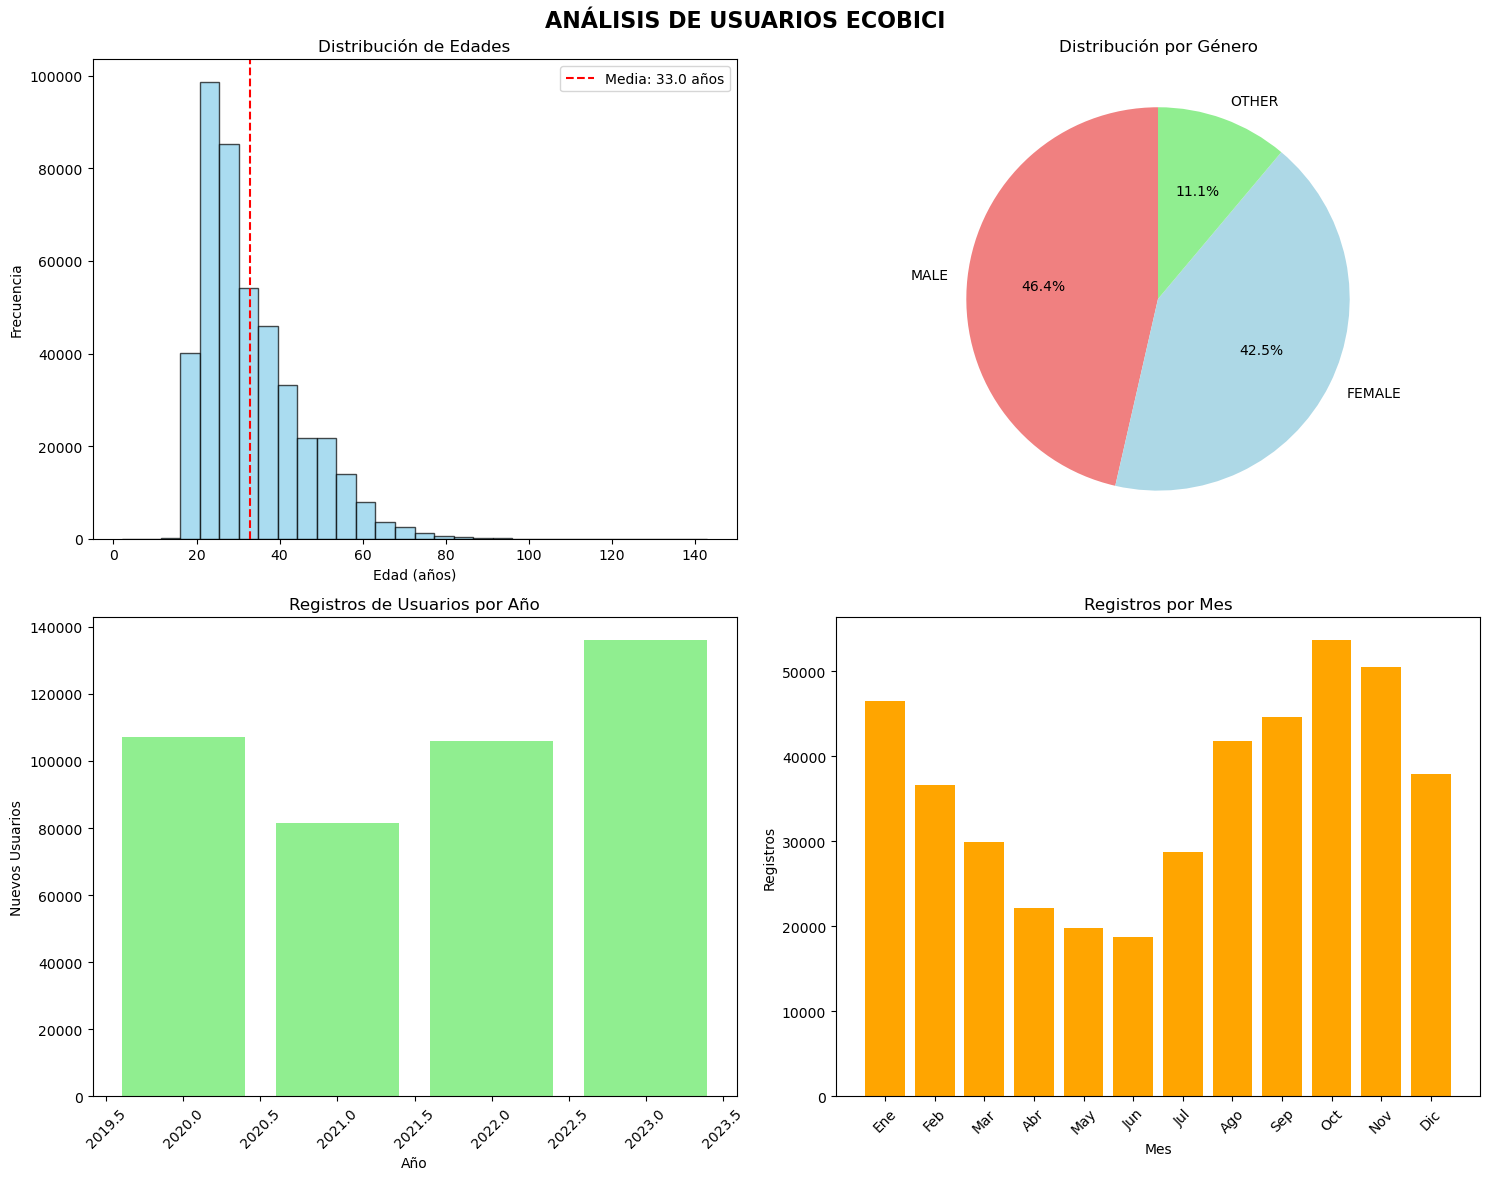

Generando análisis temporal...


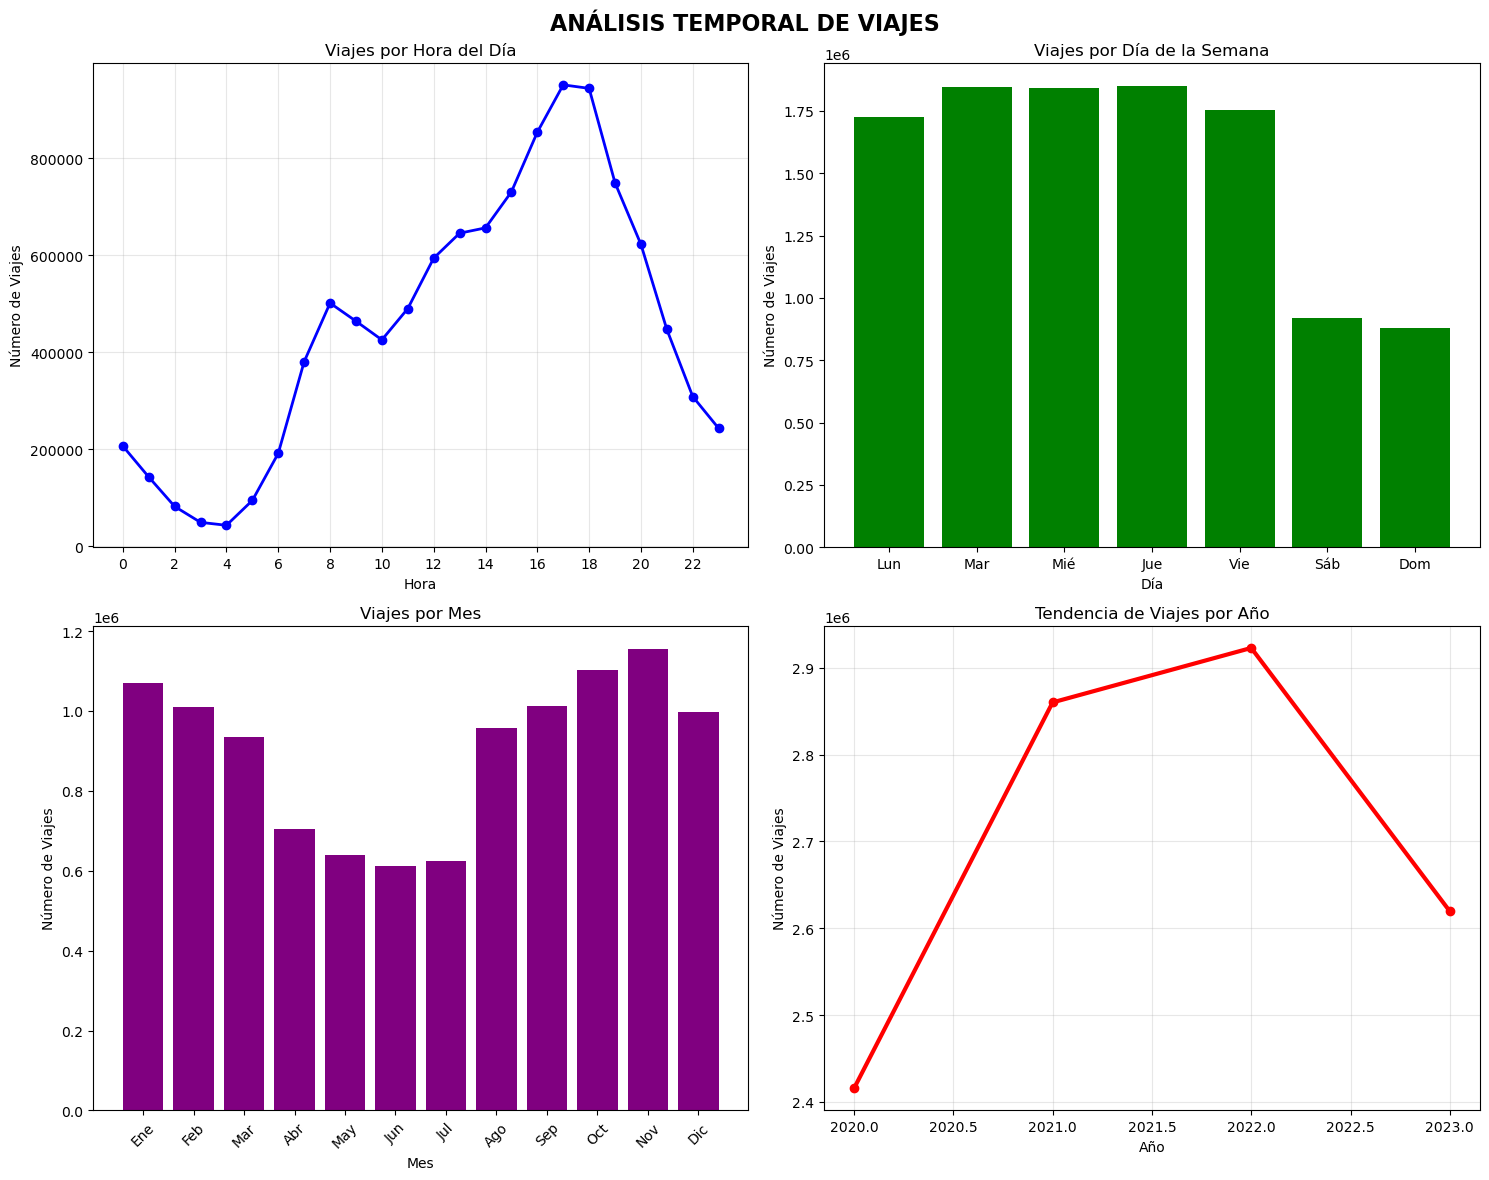

Generando análisis de estaciones...


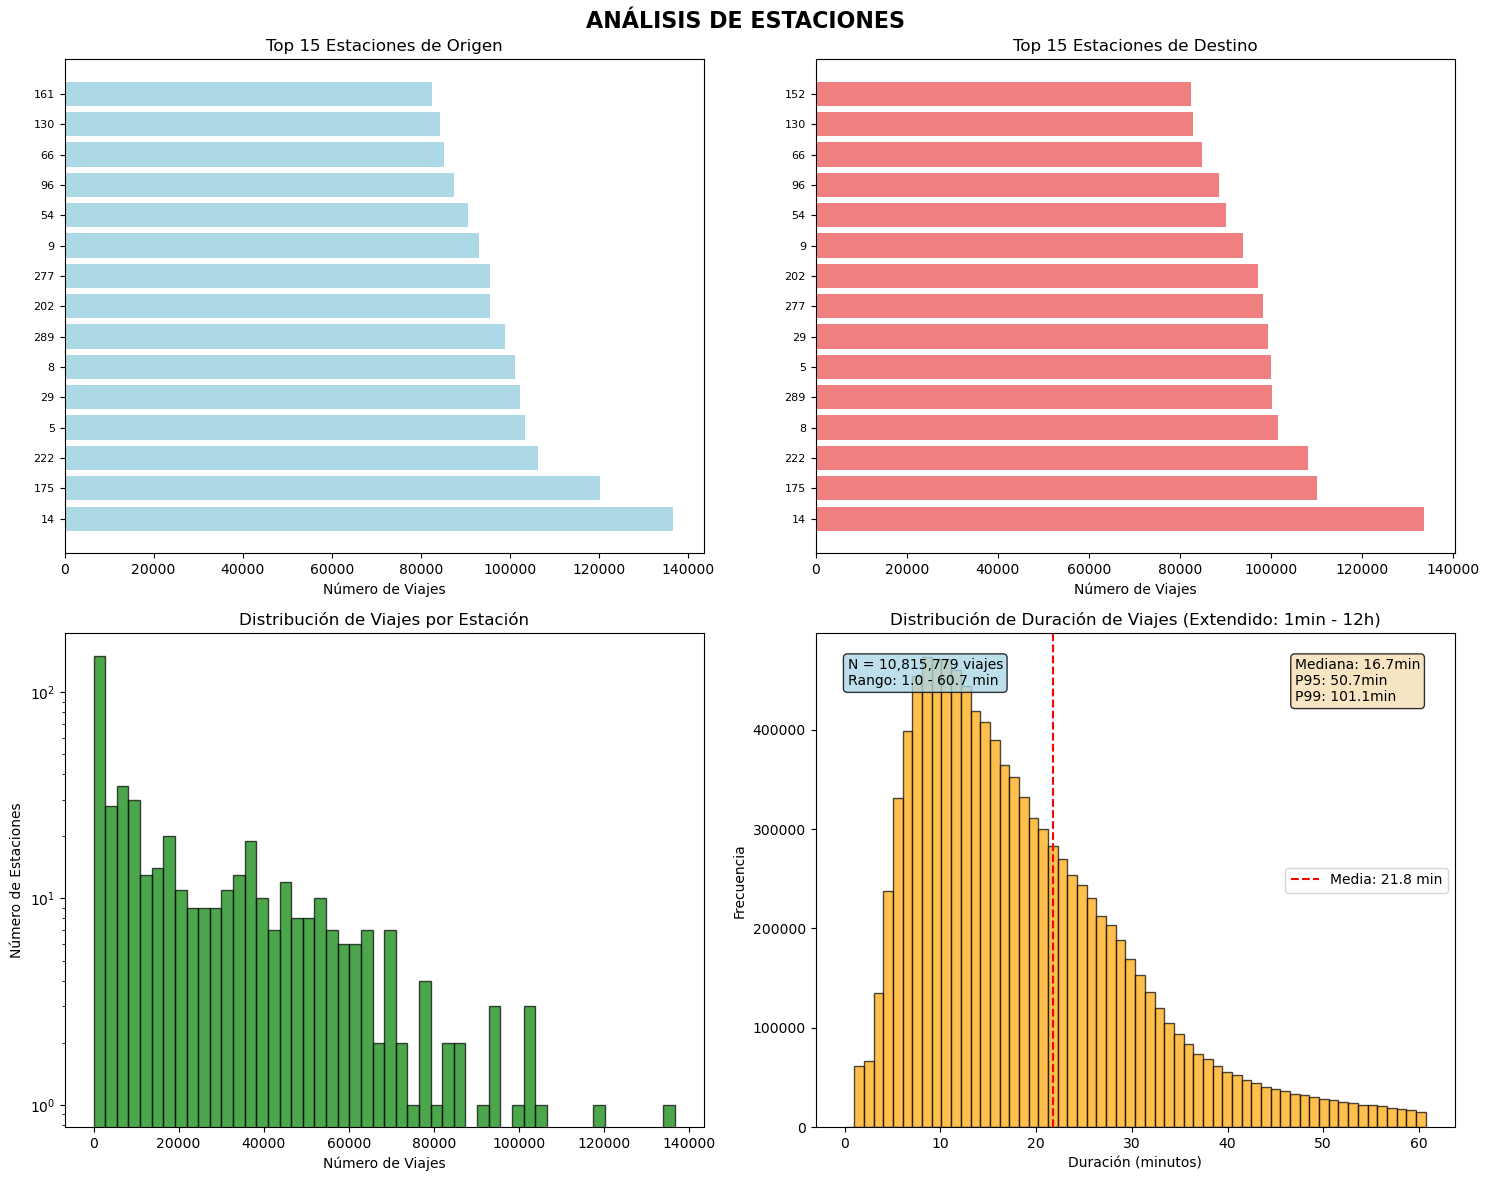

Generando heatmap de actividad...


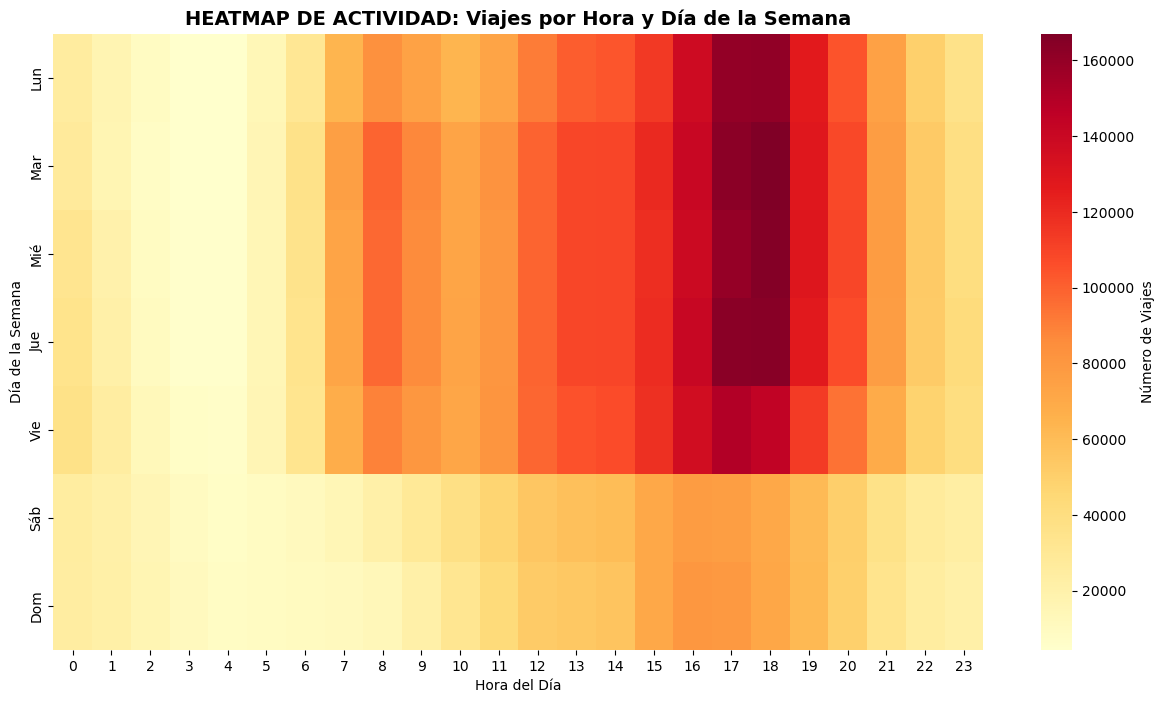


ESTADÍSTICAS RESUMEN
USUARIOS:
   • Total usuarios: 430,806
   • Edad promedio: 33.0 años
   • Distribución de género:
     - MALE: 199,987 (46.4%)
     - FEMALE: 182,907 (42.5%)
     - OTHER: 47,910 (11.1%)

VIAJES:
   • Total viajes: 10,817,950
   • Período: 2020-01-01 00:00:08 - 2023-12-30 23:59:32
   • Promedio viajes/día: 7,410
   • Estaciones únicas (origen): 484
   • Estaciones únicas (destino): 485
   • Duración promedio: 21.8 minutos


In [12]:
# combine train and validation data first, then analyze
users_combined = pd.concat([users_train, users_val], axis=0)
trips_combined = pd.concat([trips_train, trips_val], axis=0)

# analyze combined data
processed_users = analyze_users_for_visualization(users_combined)
processed_trips = analyze_trips_for_visualization(trips_combined)

# print training statistics
print(f"\nEstadísticas de entrenamiento:")
print(f"Usuarios en train: {users_train.shape}")
print(f"Viajes en train: {trips_train.shape}")

# generate analysis plots
print("\nGenerando análisis de usuarios...")
plot_user_analysis(processed_users, save_plots=False, output_dir=None)

print("Generando análisis temporal...")
plot_temporal_analysis(processed_trips, save_plots=False, output_dir=None)

print("Generando análisis de estaciones...")
plot_station_analysis(processed_trips, save_plots=False, output_dir=None)

print("Generando heatmap de actividad...")
plot_activity_heatmap(processed_trips, save_plots=False, output_dir=None)

# print summary statistics
print_summary_statistics(users_combined, processed_users, trips_combined, processed_trips)


In [13]:
len(trips_df['id_estacion_origen'].unique())
trips_df.head()

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,7210548,1582,2020-01-24 21:54:39,27,027 - Montevideo,Cordoba Av. & Montevideo,-58.390089,-34.599068,2020-01-24 22:21:01,3,003 - ADUANA,Moreno & Av Paseo Colon,-58.368260,-34.611032,192009,ICONIC,FEMALE
1,7199093,204,2020-01-24 07:04:19,151,151 - AIME PAINÉ,"Villaflor, Azucena & Paine, Aime",-58.361285,-34.611815,2020-01-24 07:07:43,3,003 - ADUANA,Moreno & Av Paseo Colon,-58.368260,-34.611032,36380,ICONIC,MALE
2,7196805,1790,2020-01-24 00:15:17,111,111 - MACACHA GUEMES,Machaca Guemes 350,-58.364686,-34.605488,2020-01-24 00:45:07,3,003 - ADUANA,Moreno & Av Paseo Colon,-58.368260,-34.611032,460080,ICONIC,MALE
3,7203598,10688,2020-01-24 12:38:16,285,400 - Reserva Ecologica,"Achaval Rodriguez, T., Dr. Av. 1520",-58.356175,-34.617212,2020-01-24 15:36:24,4,004 - Plaza Roma,Lavalle & Bouchard,-58.368781,-34.601822,3857,ICONIC,MALE
4,7200335,673,2020-01-24 08:31:01,171,171 - Pasteur,519 Pasteur,-58.399755,-34.603281,2020-01-24 08:42:14,7,007 - OBELISCO,CARLOS PELEGRINI 215,-58.381098,-34.606498,391034,ICONIC,FEMALE


In [14]:
trips_with_weather.to_csv('../data/processed/trips_with_weather.csv', index=False)

KeyboardInterrupt: 

In [15]:
# Análisis de distribución de tiempo entre arribos por estación
print("🚴 ANÁLISIS DE TIEMPO ENTRE ARRIBOS POR ESTACIÓN")
print("=" * 60)

# Función para calcular tiempo entre arribos en cada estación
def calculate_arrival_intervals_by_station(trips_df, sample_stations=20, max_trips_per_station=5000):
    """
    Calcula los intervalos de tiempo entre arribos consecutivos para cada estación
    
    Parameters:
    - trips_df: DataFrame con los datos de viajes
    - sample_stations: Número de estaciones a analizar (las más populares)
    - max_trips_per_station: Máximo número de viajes por estación para el análisis
    
    Returns:
    - intervals_data: DataFrame con los intervalos por estación
    """
    
    # Seleccionar las estaciones más populares
    top_stations = trips_df['id_estacion_origen'].value_counts().head(sample_stations).index
    
    intervals_list = []
    
    for station_id in top_stations:
        # Filtrar viajes de esta estación
        station_trips = trips_df[trips_df['id_estacion_origen'] == station_id].copy()
        
        # Tomar una muestra para evitar análisis demasiado largos
        if len(station_trips) > max_trips_per_station:
            station_trips = station_trips.sample(n=max_trips_per_station, random_state=42)
        
        # Ordenar por fecha y hora
        station_trips = station_trips.sort_values('fecha_origen_recorrido')
        
        # Calcular intervalos entre arribos consecutivos
        station_trips['fecha_dt'] = pd.to_datetime(station_trips['fecha_origen_recorrido'])
        station_trips['next_arrival'] = station_trips['fecha_dt'].shift(-1)
        station_trips['interval_minutes'] = (station_trips['next_arrival'] - station_trips['fecha_dt']).dt.total_seconds() / 60
        
        # Filtrar intervalos válidos (eliminar outliers extremos)
        valid_intervals = station_trips['interval_minutes'].dropna()
        valid_intervals = valid_intervals[(valid_intervals > 0) & (valid_intervals < 480)]  # Entre 0 y 8 horas
        
        # Agregar a la lista
        for interval in valid_intervals:
            intervals_list.append({
                'station_id': station_id,
                'station_name': station_trips['nombre_estacion_origen'].iloc[0],
                'interval_minutes': interval
            })
    
    return pd.DataFrame(intervals_list)

# Calcular intervalos para un subconjunto de datos (para rendimiento)
print("Calculando intervalos de tiempo entre arribos...")
sample_size = min(500000, len(trips_filtered))  # Usar máximo 500k viajes
trips_sample = trips_filtered.sample(n=sample_size, random_state=42)

intervals_df = calculate_arrival_intervals_by_station(trips_sample, sample_stations=15, max_trips_per_station=3000)

print(f"Análisis completado para {intervals_df['station_id'].nunique()} estaciones")
print(f"Total de intervalos calculados: {len(intervals_df):,}")

# Estadísticas básicas por estación
station_stats = intervals_df.groupby(['station_id', 'station_name'])['interval_minutes'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

print("\nEstadísticas de intervalos por estación (primeras 10):")
print(station_stats.head(10))


🚴 ANÁLISIS DE TIEMPO ENTRE ARRIBOS POR ESTACIÓN
Calculando intervalos de tiempo entre arribos...
Análisis completado para 15 estaciones
Total de intervalos calculados: 24,207

Estadísticas de intervalos por estación (primeras 10):
                                      count    mean  median     std   min  \
station_id station_name                                                     
5          005 - Plaza Italia          1560  169.42  138.38  129.25  0.07   
8          008 - Congreso              1648  168.94  137.02  128.76  0.02   
9          009 - Parque Las Heras      1588  167.32  135.27  128.33  0.05   
14         014 - Pacifico              1557  180.26  153.73  132.74  0.08   
29         029 - Parque Centenario     1603  157.54  127.72  127.47  0.02   
54         054 - Acuña de Figueroa     1582  174.93  143.12  131.77  0.12   
66         066 - Billinghurst          1551  177.80  146.72  134.25  0.22   
96         096 - Carlos Gardel         1627  170.80  143.82  130.25  0.05   

📊 VISUALIZACIÓN DE DISTRIBUCIONES POR ESTACIÓN


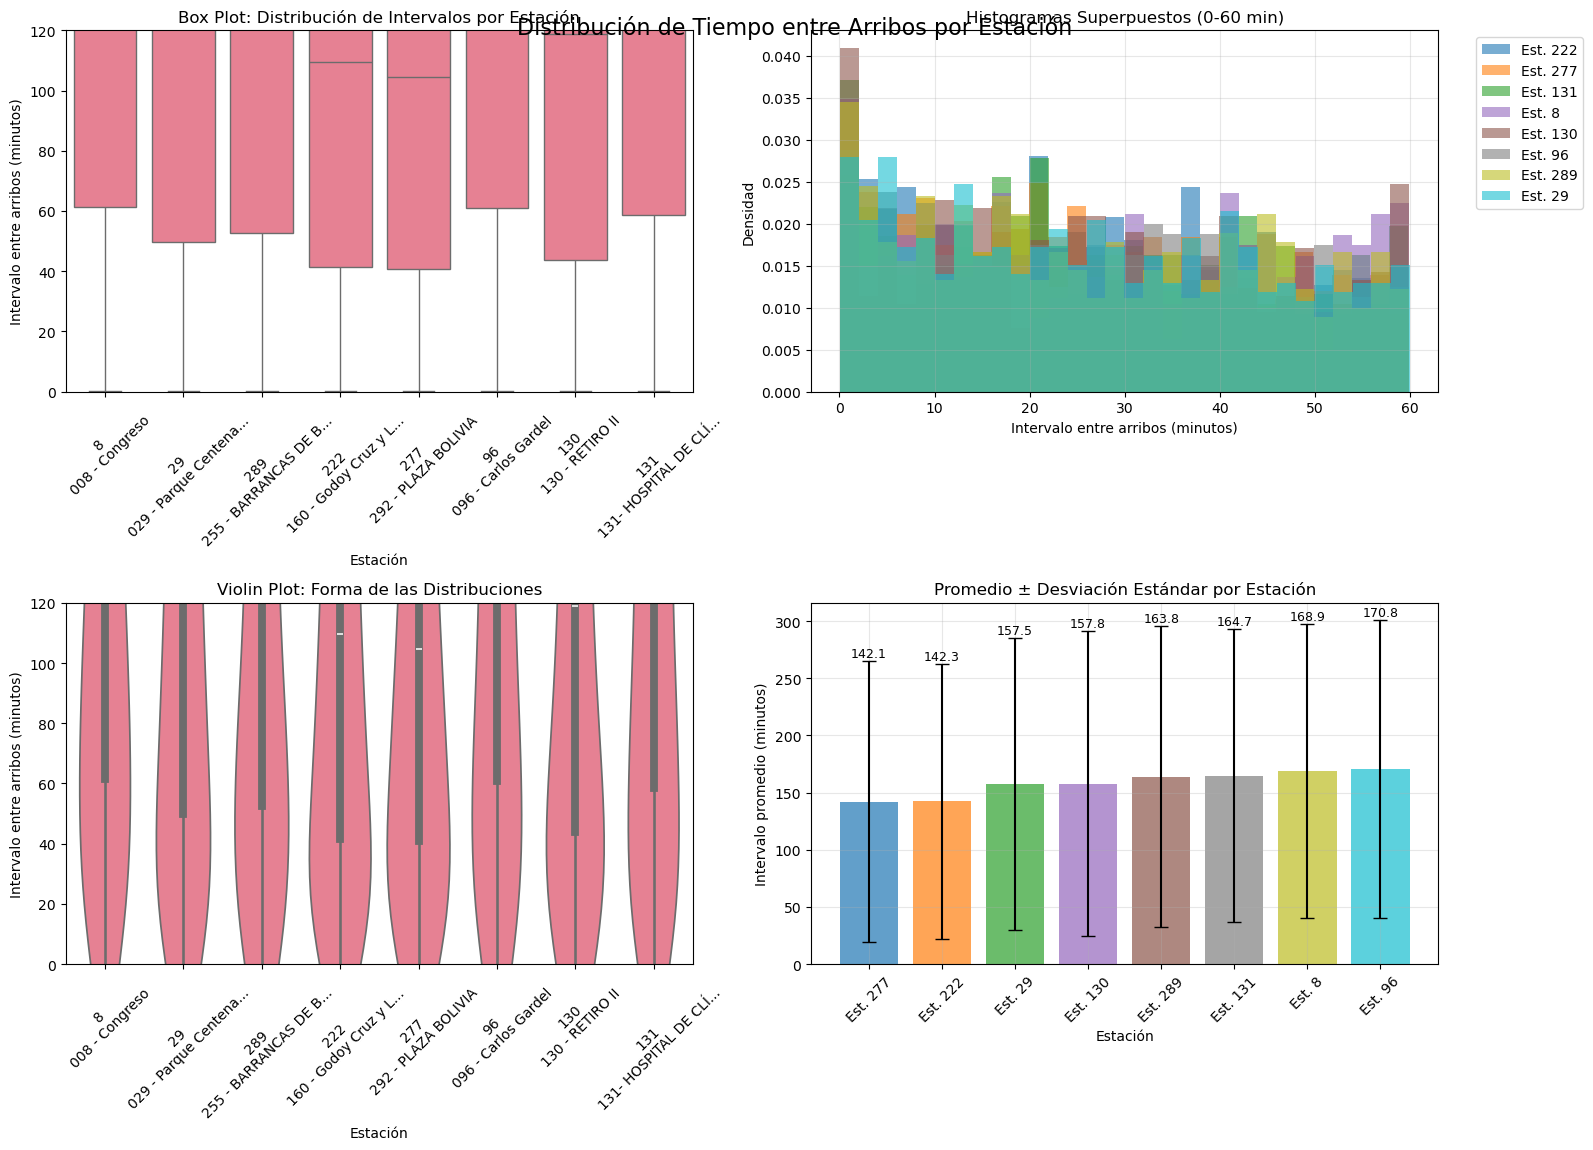


📈 RESUMEN COMPARATIVO DE ESTACIONES:
                                          count    mean  median     std
station_id station_name                                                
277        292 - PLAZA BOLIVIA             1678  142.10  104.52  123.17
222        160 - Godoy Cruz y Libertador   1730  142.27  109.64  120.29
202        001 - FACULTAD DE DERECHO       1585  149.14  110.95  124.36
29         029 - Parque Centenario         1603  157.54  127.72  127.47
130        130 - RETIRO II                 1630  157.77  118.88  133.52
289        255 - BARRANCAS DE BELGRANO     1620  163.83  130.74  131.77
131        131- HOSPITAL DE CLÍNICAS       1675  164.73  137.27  128.26
9          009 - Parque Las Heras          1588  167.32  135.27  128.33
8          008 - Congreso                  1648  168.94  137.02  128.76
5          005 - Plaza Italia              1560  169.42  138.38  129.25

🔍 INSIGHTS PRINCIPALES:
• Estación con intervalos más cortos: 292 - PLAZA BOLIVIA (Promedio: 142.

In [16]:
# Visualización de distribuciones de tiempo entre arribos
print("📊 VISUALIZACIÓN DE DISTRIBUCIONES POR ESTACIÓN")
print("=" * 50)

# Crear gráficos comparativos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribución de Tiempo entre Arribos por Estación', fontsize=16, y=0.95)

# 1. Box plot comparativo
ax1 = axes[0, 0]
stations_for_plot = intervals_df['station_id'].value_counts().head(8).index
plot_data = intervals_df[intervals_df['station_id'].isin(stations_for_plot)]

# Crear etiquetas más cortas para las estaciones
station_labels = {}
for station_id in stations_for_plot:
    name = intervals_df[intervals_df['station_id'] == station_id]['station_name'].iloc[0]
    short_name = name[:20] + '...' if len(name) > 20 else name
    station_labels[station_id] = f"{station_id}\n{short_name}"

plot_data['station_label'] = plot_data['station_id'].map(station_labels)

sns.boxplot(data=plot_data, x='station_label', y='interval_minutes', ax=ax1)
ax1.set_title('Box Plot: Distribución de Intervalos por Estación')
ax1.set_xlabel('Estación')
ax1.set_ylabel('Intervalo entre arribos (minutos)')
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylim(0, 120)  # Limitar a 2 horas para mejor visualización

# 2. Histograma superpuesto
ax2 = axes[0, 1]
colors = plt.cm.tab10(np.linspace(0, 1, len(stations_for_plot)))

for i, station_id in enumerate(stations_for_plot):
    station_data = intervals_df[intervals_df['station_id'] == station_id]['interval_minutes']
    station_data_filtered = station_data[station_data <= 60]  # Solo hasta 1 hora
    
    ax2.hist(station_data_filtered, bins=30, alpha=0.6, 
             label=f'Est. {station_id}', color=colors[i], density=True)

ax2.set_title('Histogramas Superpuestos (0-60 min)')
ax2.set_xlabel('Intervalo entre arribos (minutos)')
ax2.set_ylabel('Densidad')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

# 3. Violin plot
ax3 = axes[1, 0]
sns.violinplot(data=plot_data, x='station_label', y='interval_minutes', ax=ax3)
ax3.set_title('Violin Plot: Forma de las Distribuciones')
ax3.set_xlabel('Estación')
ax3.set_ylabel('Intervalo entre arribos (minutos)')
ax3.tick_params(axis='x', rotation=45)
ax3.set_ylim(0, 120)

# 4. Gráfico de medias con barras de error
ax4 = axes[1, 1]
summary_stats = intervals_df.groupby('station_id')['interval_minutes'].agg(['mean', 'std', 'count']).reset_index()
summary_stats = summary_stats[summary_stats['station_id'].isin(stations_for_plot)]
summary_stats = summary_stats.sort_values('mean')

bars = ax4.bar(range(len(summary_stats)), summary_stats['mean'], 
               yerr=summary_stats['std'], capsize=5, 
               color=colors[:len(summary_stats)], alpha=0.7)

ax4.set_title('Promedio ± Desviación Estándar por Estación')
ax4.set_xlabel('Estación')
ax4.set_ylabel('Intervalo promedio (minutos)')
ax4.set_xticks(range(len(summary_stats)))
ax4.set_xticklabels([f'Est. {sid}' for sid in summary_stats['station_id']], rotation=45)
ax4.grid(True, alpha=0.3)

# Agregar valores en las barras
for i, (bar, mean_val) in enumerate(zip(bars, summary_stats['mean'])):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + summary_stats['std'].iloc[i] + 1,
             f'{mean_val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Resumen estadístico
print("\n📈 RESUMEN COMPARATIVO DE ESTACIONES:")
print("=" * 50)

summary_comparison = intervals_df.groupby(['station_id', 'station_name'])['interval_minutes'].agg([
    'count', 'mean', 'median', 'std'
]).round(2)

summary_comparison = summary_comparison.sort_values('mean')
print(summary_comparison.head(10))

print(f"\n🔍 INSIGHTS PRINCIPALES:")
print(f"• Estación con intervalos más cortos: {summary_comparison.index[0][1]} (Promedio: {summary_comparison['mean'].iloc[0]:.1f} min)")
print(f"• Estación with intervalos más largos: {summary_comparison.index[-1][1]} (Promedio: {summary_comparison['mean'].iloc[-1]:.1f} min)")
print(f"• Rango de promedios: {summary_comparison['mean'].min():.1f} - {summary_comparison['mean'].max():.1f} minutos")
print(f"• Estación más consistente (menor std): {summary_comparison.loc[summary_comparison['std'].idxmin()][1]} (Std: {summary_comparison['std'].min():.1f})")
print(f"• Estación más variable (mayor std): {summary_comparison.loc[summary_comparison['std'].idxmax()][1]} (Std: {summary_comparison['std'].max():.1f})")


📊 DISTRIBUCIÓN TOTAL DE INTERVALOS ENTRE ARRIBOS


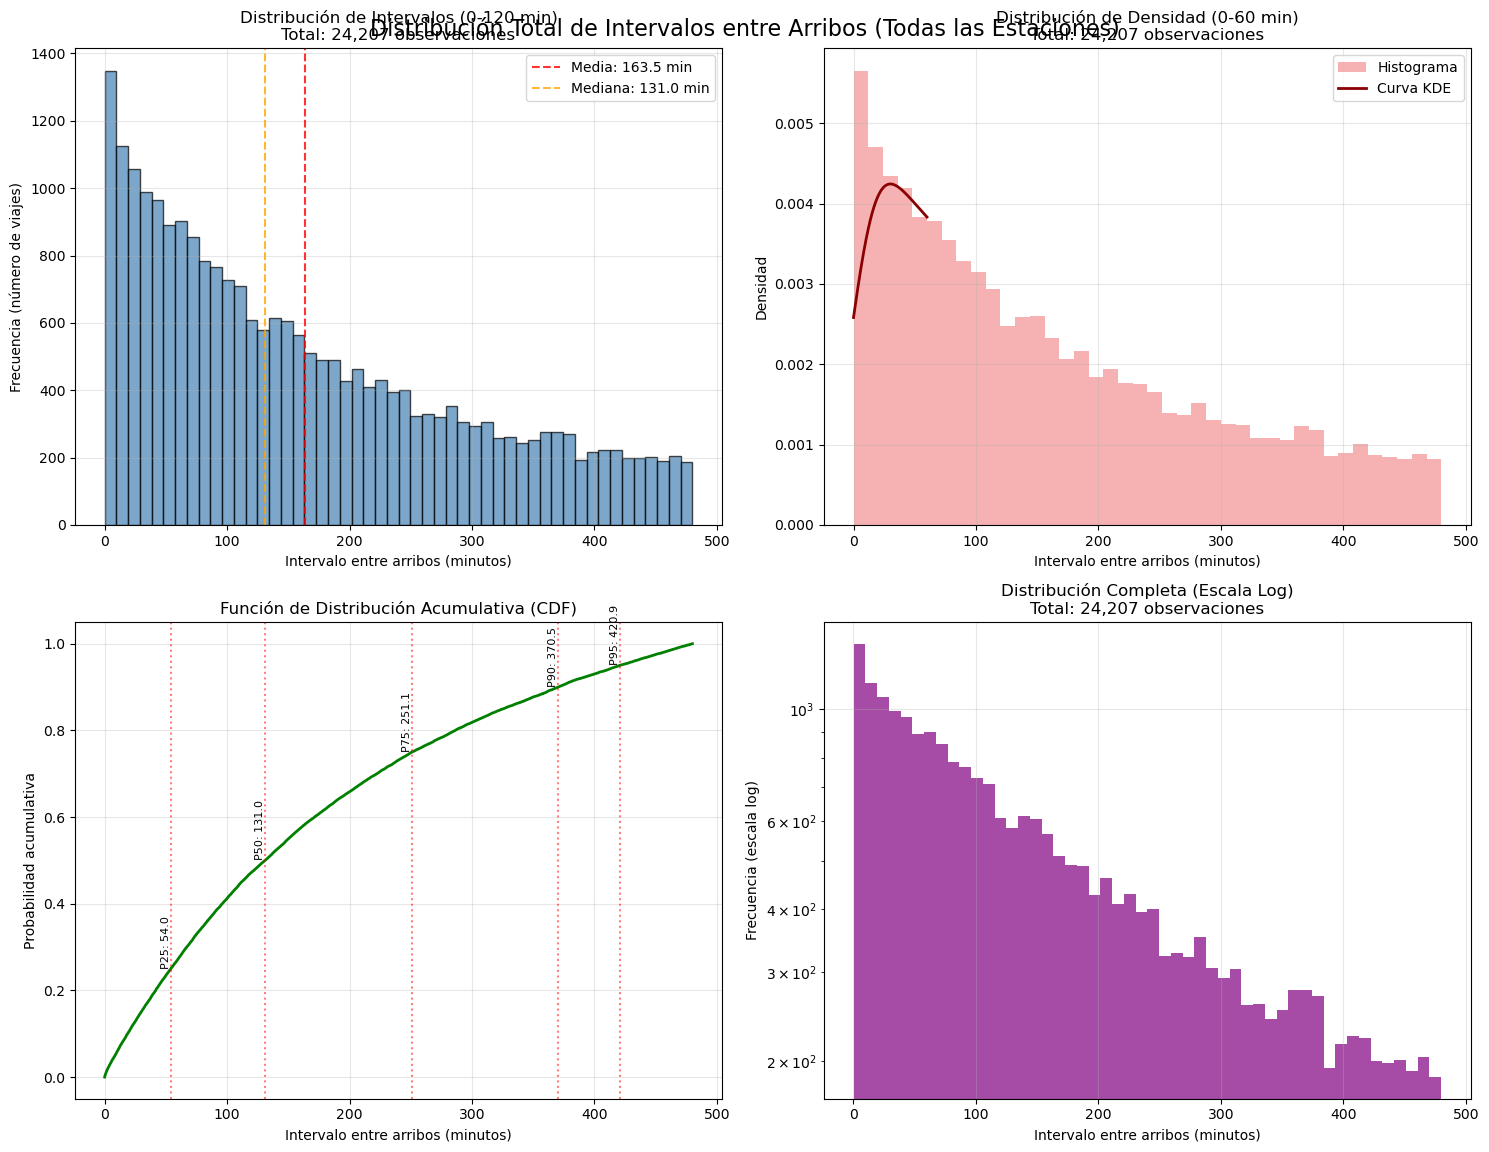


📈 ESTADÍSTICAS DETALLADAS DE LA DISTRIBUCIÓN AGREGADA:
• Total observaciones: 24,207
• Media: 163.51 minutos
• Mediana: 131.03 minutos
• Desviación estándar: 129.92 minutos
• Mínimo: 0.02 minutos
• Máximo: 479.93 minutos
• Rango intercuartílico (IQR): 197.08 minutos

📊 PERCENTILES:
• P10: 18.76 minutos
• P25: 54.05 minutos
• P50: 131.03 minutos
• P75: 251.13 minutos
• P90: 370.50 minutos
• P95: 420.89 minutos
• P99: 467.81 minutos

⏱️ DISTRIBUCIÓN POR RANGOS DE TIEMPO:
• 0-5 min (muy frecuente): 789 observaciones (3.3%)
• 5-15 min (frecuente): 1,213 observaciones (5.0%)
• 15-30 min (moderado): 1,651 observaciones (6.8%)
• 30-60 min (espaciado): 2,941 observaciones (12.1%)
• 1-2 horas (poco frecuente): 4,852 observaciones (20.0%)
• >2 horas (raro): 12,761 observaciones (52.7%)

🎯 INSIGHTS CLAVE:
• El 50% de los arribos ocurren con intervalos ≤ 131.0 minutos
• El 90% de los arribos ocurren con intervalos ≤ 370.5 minutos
• El intervalo más común está entre 54.0 y 251.1 minutos (IQR)

📐 A

In [19]:
# Distribución agregada de intervalos entre arribos (todas las estaciones combinadas)
print("📊 DISTRIBUCIÓN TOTAL DE INTERVALOS ENTRE ARRIBOS")
print("=" * 55)

# Crear figura con múltiples subplots para diferentes vistas de la distribución
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Distribución Total de Intervalos entre Arribos (Todas las Estaciones)', fontsize=16, y=0.95)

# Datos agregados de todas las estaciones
all_intervals = intervals_df['interval_minutes'].copy()

# 1. Histograma principal (0-120 minutos)
ax1 = axes[0, 0]
intervals_filtered = all_intervals
n, bins, patches = ax1.hist(intervals_filtered, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_title(f'Distribución de Intervalos (0-120 min)\nTotal: {len(intervals_filtered):,} observaciones')
ax1.set_xlabel('Intervalo entre arribos (minutos)')
ax1.set_ylabel('Frecuencia (número de viajes)')
ax1.grid(True, alpha=0.3)

# Agregar estadísticas al gráfico
mean_val = intervals_filtered.mean()
median_val = intervals_filtered.median()
ax1.axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Media: {mean_val:.1f} min')
ax1.axvline(median_val, color='orange', linestyle='--', alpha=0.8, label=f'Mediana: {median_val:.1f} min')
ax1.legend()

# 2. Distribución de densidad (curva suave)
ax2 = axes[0, 1]
intervals_density = all_intervals # Solo hasta 1 hora para mejor visualización
ax2.hist(intervals_density, bins=40, density=True, alpha=0.6, color='lightcoral', label='Histograma')
ax2.set_title(f'Distribución de Densidad (0-60 min)\nTotal: {len(intervals_density):,} observaciones')
ax2.set_xlabel('Intervalo entre arribos (minutos)')
ax2.set_ylabel('Densidad')
ax2.grid(True, alpha=0.3)

# Agregar curva de densidad suavizada usando KDE
from scipy.stats import gaussian_kde
if len(intervals_density) > 0:
    kde = gaussian_kde(intervals_density)
    x_range = np.linspace(0, 60, 300)
    density = kde(x_range)
    ax2.plot(x_range, density, color='darkred', linewidth=2, label='Curva KDE')
    ax2.legend()

# 3. Distribución acumulativa (CDF)
ax3 = axes[1, 0]
sorted_intervals = np.sort(intervals_filtered)
cumulative = np.arange(1, len(sorted_intervals) + 1) / len(sorted_intervals)
ax3.plot(sorted_intervals, cumulative, color='green', linewidth=2)
ax3.set_title('Función de Distribución Acumulativa (CDF)')
ax3.set_xlabel('Intervalo entre arribos (minutos)')
ax3.set_ylabel('Probabilidad acumulativa')
ax3.grid(True, alpha=0.3)

# Agregar percentiles importantes
percentiles = [25, 50, 75, 90, 95]
for p in percentiles:
    val = np.percentile(intervals_filtered, p)
    ax3.axvline(val, color='red', alpha=0.5, linestyle=':')
    ax3.text(val, p/100, f'P{p}: {val:.1f}', rotation=90, ha='right', va='bottom', fontsize=8)

# 4. Log-scale para ver toda la distribución incluyendo colas largas
ax4 = axes[1, 1]
all_intervals_full = all_intervals[all_intervals > 0]  # Eliminar ceros para log
ax4.hist(all_intervals_full, bins=50, alpha=0.7, color='purple')
ax4.set_yscale('log')
ax4.set_title(f'Distribución Completa (Escala Log)\nTotal: {len(all_intervals_full):,} observaciones')
ax4.set_xlabel('Intervalo entre arribos (minutos)')
ax4.set_ylabel('Frecuencia (escala log)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas detalladas
print("\n📈 ESTADÍSTICAS DETALLADAS DE LA DISTRIBUCIÓN AGREGADA:")
print("=" * 60)

# Estadísticas básicas
stats_basic = {
    'Total observaciones': len(all_intervals),
    'Media': all_intervals.mean(),
    'Mediana': all_intervals.median(),
    'Desviación estándar': all_intervals.std(),
    'Mínimo': all_intervals.min(),
    'Máximo': all_intervals.max(),
    'Rango intercuartílico (IQR)': all_intervals.quantile(0.75) - all_intervals.quantile(0.25)
}

for key, value in stats_basic.items():
    if isinstance(value, float):
        print(f"• {key}: {value:.2f} {'minutos' if 'Total' not in key else ''}")
    else:
        print(f"• {key}: {value:,}")

# Percentiles
print(f"\n📊 PERCENTILES:")
percentiles_to_show = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles_to_show:
    val = all_intervals.quantile(p/100)
    print(f"• P{p}: {val:.2f} minutos")

# Distribución por rangos de tiempo
print(f"\n⏱️ DISTRIBUCIÓN POR RANGOS DE TIEMPO:")
ranges = [
    (0, 5, "0-5 min (muy frecuente)"),
    (5, 15, "5-15 min (frecuente)"),
    (15, 30, "15-30 min (moderado)"),
    (30, 60, "30-60 min (espaciado)"),
    (60, 120, "1-2 horas (poco frecuente)"),
    (120, float('inf'), ">2 horas (raro)")
]

total_count = len(all_intervals)
for min_val, max_val, label in ranges:
    if max_val == float('inf'):
        count = len(all_intervals[all_intervals >= min_val])
    else:
        count = len(all_intervals[(all_intervals >= min_val) & (all_intervals < max_val)])
    percentage = (count / total_count) * 100
    print(f"• {label}: {count:,} observaciones ({percentage:.1f}%)")

print(f"\n🎯 INSIGHTS CLAVE:")
print(f"• El 50% de los arribos ocurren con intervalos ≤ {all_intervals.median():.1f} minutos")
print(f"• El 90% de los arribos ocurren con intervalos ≤ {all_intervals.quantile(0.9):.1f} minutos")
print(f"• El intervalo más común está entre {all_intervals.quantile(0.25):.1f} y {all_intervals.quantile(0.75):.1f} minutos (IQR)")

# Análisis de distribución estadística
from scipy import stats
print(f"\n📐 ANÁLISIS DE FORMA DE LA DISTRIBUCIÓN:")
skewness = stats.skew(all_intervals.dropna())
kurtosis = stats.kurtosis(all_intervals.dropna())
print(f"• Asimetría (skewness): {skewness:.3f} {'(sesgada a la derecha)' if skewness > 0 else '(sesgada a la izquierda)' if skewness < 0 else '(simétrica)'}")
print(f"• Curtosis: {kurtosis:.3f} {'(leptocúrtica - colas pesadas)' if kurtosis > 0 else '(platicúrtica - colas ligeras)' if kurtosis < 0 else '(mesocúrtica - normal)'}")
